# RGB Testing v4 — CNN Softmax dan SVM Standalone

Notebook ini membandingkan dua classifier RGB dari checkpoint CNN v4 yang sama: **CNN Softmax** dan **CNN feature + SVM standalone**. SVM menggunakan 512-D `svm_features` dan rata-rata inference pada gambar original + horizontal flip (representasi B), sama seperti pada RGB Training v4 yang telah diperbaiki. Model SVM harus sudah di-fit pada 50.000 official training samples. Evaluasi tidak melakukan fitting ulang atau pemilihan hyperparameter. **Official test telah digunakan pada eksperimen terdahulu**, sehingga hasil ini merupakan evaluasi post-exposure.

## 1. Muat CNN RGB v4 dan verifikasi hash

Gunakan checkpoint RGB v4 dan pastikan SHA-256 sama dengan laporan CNN. Artefak v1/v2/v3 tidak digunakan atau diubah. Sebaiknya jalankan notebook ini setelah konfigurasi fusion terkunci.

In [1]:
from pathlib import Path
import json,hashlib
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ROOT=Path.cwd().resolve()
if not (ROOT/'outputs'/'cifar10_rgb_residual_v4').is_dir() and (ROOT/'tugas-7'/'outputs'/'cifar10_rgb_residual_v4').is_dir():ROOT=ROOT/'tugas-7'
OUT=ROOT/'outputs'/'cifar10_rgb_residual_v4'/'rgb'
ckpt=OUT/'model'/'cnn.keras'
meta=json.loads((OUT/'laporan'/'cnn_training.json').read_text(encoding='utf-8'))
def sha256_file(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''):h.update(block)
    return h.hexdigest()
if sha256_file(ckpt)!=meta['cnn_sha256']:raise ValueError('Hash CNN RGB v4 salah')
model=tf.keras.models.load_model(ckpt,compile=False)
print('Checkpoint RGB v4 siap:',meta['cnn_sha256'][:16])

I0000 00:00:1791511986.987756  256420 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791511987.028657  256420 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791511988.134255  256420 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791511989.643064  256420 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1980 MB mem

Checkpoint RGB v4 siap: cea218a9171acf35


## 2. Muat official test

Hanya 10.000 gambar test yang digunakan, tanpa fitting dan tanpa memilih ulang checkpoint.

In [2]:
from tensorflow.keras.datasets import cifar10
(_,_),(x_test,y_test)=cifar10.load_data()
y_test=y_test.ravel().astype(np.int64)
x_test=x_test.astype(np.float32)/255.0
assert x_test.shape==(10000,32,32,3)

## 3. Prediksi CNN Softmax

Inferensi menggunakan `training=False`. Hasil prediksi tidak memengaruhi preprocessing dan training SVM fusion.

In [3]:
predictions=np.empty((10000,10),dtype=np.float32)
for start in range(0,10000,128):
    end=min(start+128,10000)
    predictions[start:end]=model(x_test[start:end],training=False).numpy().astype(np.float32)
y_pred=np.argmax(predictions,axis=1)
assert y_pred.shape==(10000,)

E0000 00:00:1791511992.594810  256420 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1791511992.644206  256420 cuda_dnn.cc:461] Loaded cuDNN version 92600


## 4. Laporan CNN Softmax dan confusion matrix

Akurasi CNN Softmax adalah evaluasi model CNN secara langsung dan **bukan** akurasi SVM. Laporan disimpan pada file tersendiri agar tidak tercampur dengan hasil RGB CNN + SVM maupun feature engineering fusion.

RGB v4 CNN Softmax official test: 92.02%
              precision    recall  f1-score   support

           0     0.9115    0.9370    0.9241      1000
           1     0.9727    0.9620    0.9673      1000
           2     0.8978    0.8960    0.8969      1000
           3     0.8170    0.8350    0.8259      1000
           4     0.9250    0.9250    0.9250      1000
           5     0.8644    0.8800    0.8722      1000
           6     0.9519    0.9310    0.9414      1000
           7     0.9477    0.9430    0.9454      1000
           8     0.9518    0.9480    0.9499      1000
           9     0.9682    0.9450    0.9565      1000

    accuracy                         0.9202     10000
   macro avg     0.9208    0.9202    0.9204     10000
weighted avg     0.9208    0.9202    0.9204     10000



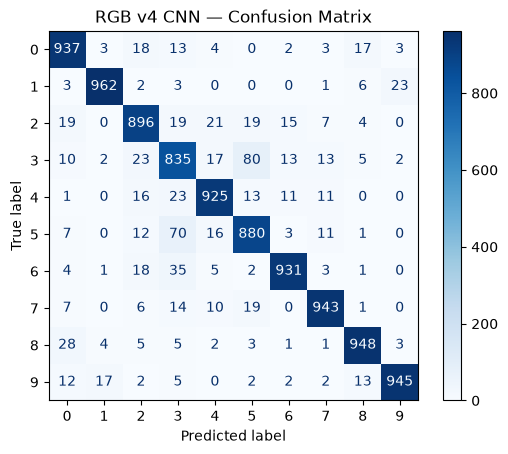

In [4]:
cnn_accuracy = float(accuracy_score(y_test, y_pred))
cnn_metrics = {
    'run_id': 'cifar10_rgb_residual_v4', 'cnn_sha256': meta['cnn_sha256'],
    'official_test_accuracy': cnn_accuracy,
    'macro_f1': float(f1_score(y_test, y_pred, average='macro')),
    'n_test': 10000, 'post_exposure': True, 'classifier': 'CNN Softmax',
}
cnn_report_path = OUT / 'laporan' / 'cnn_test.json'
if cnn_report_path.exists():
    old = json.loads(cnn_report_path.read_text(encoding='utf-8'))
    if old != cnn_metrics:
        raise ValueError('Laporan CNN test sebelumnya berbeda; tidak menimpanya')
else:
    cnn_report_path.write_text(json.dumps(cnn_metrics, indent=2), encoding='utf-8')
print('RGB v4 CNN Softmax official test:', f'{cnn_accuracy:.2%}')
print(classification_report(y_test, y_pred, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('RGB v4 CNN — Confusion Matrix')
plt.show()

## 5. Muat model SVM RGB standalone final

Muat `model/svm.joblib` yang dihasilkan RGB Training v4 dan periksa kesesuaian dengan checkpoint CNN, nama layer, representasi B, dimensi 512 serta `fit_sample_count=50000`. Seluruh preprocessing tersimpan di dalam `Pipeline`; tidak boleh membuat atau me-fit scaler baru saat testing.

In [5]:
import joblib
svm_file = OUT / 'model' / 'svm.joblib'
svm_report_file = OUT / 'laporan' / 'svm_training.json'
if not svm_file.is_file() or not svm_report_file.is_file():
    raise FileNotFoundError('Model SVM RGB v4 tidak ada. Jalankan bagian SVM dalam RGB Training v4 sampai selesai.')
svm_artifact = joblib.load(svm_file)
svm_meta = json.loads(svm_report_file.read_text(encoding='utf-8'))
for item in (svm_artifact, svm_meta):
    if (item.get('run_id') != meta['run_id']
        or item.get('cnn_sha256') != meta['cnn_sha256']
        or item.get('feature_layer') != 'svm_features'
        or item.get('feature_representation') != 'B'
        or item.get('fit_sample_count') != 50000):
        raise ValueError('Identitas model SVM RGB tidak cocok dengan checkpoint CNN v4')
if svm_artifact.get('feature_dim') != 512 or svm_meta.get('feature_dim') != 512:
    raise ValueError('Dimensi SVM RGB harus 512')
if svm_artifact.get('feature_archive_sha256') != svm_meta.get('feature_archive_sha256'):
    raise ValueError('Provenance arsip fitur model SVM tidak cocok')
svm_pipeline = svm_artifact['pipeline']
print('SVM RGB final tervalidasi. Sampel fitting:', svm_meta['fit_sample_count'])

SVM RGB final tervalidasi. Sampel fitting: 50000


## 6. Ekstraksi fitur original dan flip pada official test

Ambil output `svm_features` dari gambar RGB yang sama dengan evaluasi CNN, tanpa training CNN. Hitung representasi B dengan merata-ratakan embedding original dan horizontal flip. Gunakan `training=False` agar BatchNormalization dan augmentation layer berada dalam mode inference. Scaler dan SVM menggunakan `.predict()` saja.

In [6]:
extractor = tf.keras.Model(model.input, model.get_layer('svm_features').output)
X_test_features = np.empty((10000, 512), dtype=np.float32)
for start in range(0, 10000, 64):
    end = min(start + 64, 10000)
    batch = x_test[start:end]
    original = extractor(batch, training=False).numpy().astype(np.float32)
    flipped = extractor(np.ascontiguousarray(batch[:, :, ::-1, :]), training=False).numpy().astype(np.float32)
    X_test_features[start:end] = (original + flipped) * np.float32(0.5)
    if end % 3200 == 0 or end == 10000:
        print('Ekstraksi fitur test:', end, '/10000', flush=True)
if X_test_features.shape != (10000, 512) or not np.isfinite(X_test_features).all():
    raise ValueError('Fitur test SVM memiliki nilai atau dimensi yang tidak valid')
svm_predictions = svm_pipeline.predict(X_test_features).astype(np.int64)
print('Prediksi RGB feature + SVM selesai')

Ekstraksi fitur test: 3200 /10000
Ekstraksi fitur test: 6400 /10000
Ekstraksi fitur test: 9600 /10000
Ekstraksi fitur test: 10000 /10000
Prediksi RGB feature + SVM selesai


## 7. Laporan SVM standalone dan confusion matrix

Hitung accuracy, macro-F1, classification report, dan confusion matrix khusus **RGB CNN + SVM**. Simpan hasilnya di `svm_test.json`, terpisah dari `cnn_test.json`. Target tugas dipenuhi jika akurasi official test mencapai **≥95,00%**. Jangan menggunakan label test untuk mengubah model, bobot ensemble, ataupun hyperparameter.

RGB v4 CNN + SVM official test: 93.04%
Macro-F1: 93.04%
Target ≥95%: BELUM TERCAPAI
              precision    recall  f1-score   support

           0     0.9287    0.9380    0.9333      1000
           1     0.9681    0.9720    0.9701      1000
           2     0.9178    0.9040    0.9108      1000
           3     0.8415    0.8550    0.8482      1000
           4     0.9150    0.9470    0.9307      1000
           5     0.8968    0.8780    0.8873      1000
           6     0.9567    0.9490    0.9528      1000
           7     0.9634    0.9470    0.9551      1000
           8     0.9579    0.9560    0.9570      1000
           9     0.9599    0.9580    0.9590      1000

    accuracy                         0.9304     10000
   macro avg     0.9306    0.9304    0.9304     10000
weighted avg     0.9306    0.9304    0.9304     10000



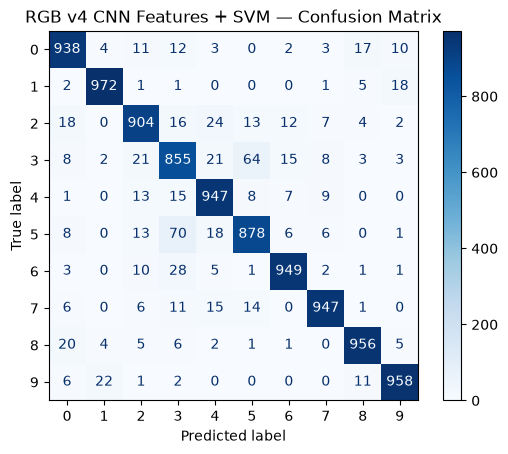

In [7]:
svm_accuracy = float(accuracy_score(y_test, svm_predictions))
svm_macro_f1 = float(f1_score(y_test, svm_predictions, average='macro'))
svm_test_metrics = {
    'run_id': meta['run_id'], 'classifier': 'RGB CNN features + SVM',
    'cnn_sha256': meta['cnn_sha256'],
    'feature_representation': 'B', 'feature_layer': 'svm_features',
    'feature_dim': 512, 'fit_sample_count': 50000,
    'official_test_accuracy': svm_accuracy, 'macro_f1': svm_macro_f1,
    'correct': int(np.sum(y_test == svm_predictions)),
    'n_test': 10000, 'target_accuracy': 0.95,
    'target_met': bool(svm_accuracy >= 0.95), 'post_exposure': True,
}
svm_test_path = OUT / 'laporan' / 'svm_test.json'
if svm_test_path.exists():
    saved = json.loads(svm_test_path.read_text(encoding='utf-8'))
    if saved != svm_test_metrics:
        raise ValueError('Laporan SVM test lama berbeda; tidak menimpanya')
else:
    svm_test_path.write_text(json.dumps(svm_test_metrics, indent=2, ensure_ascii=False), encoding='utf-8')
print('RGB v4 CNN + SVM official test:', f'{svm_accuracy:.2%}')
print('Macro-F1:', f'{svm_macro_f1:.2%}')
print('Target ≥95%:', 'TERCAPAI' if svm_accuracy >= 0.95 else 'BELUM TERCAPAI')
print(classification_report(y_test, svm_predictions, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, svm_predictions, cmap='Blues')
plt.title('RGB v4 CNN Features + SVM — Confusion Matrix')
plt.show()

## 8. Ringkasan hasil RGB v4

Bandingkan hasil **Softmax CNN** dan **SVM standalone** dengan sumber CNN yang sama. Perbandingan ini terpisah dari hasil SVM Feature Engineering yang menggabungkan RGB, AVG, NTSC, dan descriptor tambahan.

In [8]:
print('=' * 64)
print('HASIL OFFICIAL TEST RGB v4')
print('=' * 64)
print('CNN Softmax:', f'{cnn_accuracy:.2%}')
print('CNN feature + SVM:', f'{svm_accuracy:.2%}')
print('Selisih SVM - CNN (poin persentase):', round((svm_accuracy - cnn_accuracy) * 100, 2))
print('Target SVM >= 95%:', 'TERCAPAI' if svm_accuracy >= 0.95 else 'BELUM TERCAPAI')
print('Catatan: evaluasi official test bersifat post-exposure.')

HASIL OFFICIAL TEST RGB v4
CNN Softmax: 92.02%
CNN feature + SVM: 93.04%
Selisih SVM - CNN (poin persentase): 1.02
Target SVM >= 95%: BELUM TERCAPAI
Catatan: evaluasi official test bersifat post-exposure.
